##Kudzu vine model

01 - Patch construction

02 - Grid Search

03 - PSO

**04 - Simulation**

05 - Map

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt


In [ ]:
patch_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_patch_attributes_V5.csv")

D_ij = np.load("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/kudzu_D_ij_shortest_V5.npy")

In [ ]:
patch_df.head()

,patch_id,cell_area,land_area,land_prop,occyear1,occyear2,Agriculture_area,Forest_area,Freshwater_area,Marine_area,Urban_area,Agriculture_prop,Forest_prop,Freshwater_prop,Marine_prop,Urban_prop,A_i
0,0,100000000.0,100000000.0,1.0,0,0,2.531998e+06,9.663946e+07,0.0,0.0,828540.11590,0.025320,0.966395,0.0,0.0,0.008285,100.0
1,1,100000000.0,100000000.0,1.0,0,0,0.000000e+00,1.000000e+08,0.0,0.0,0.00000,0.000000,1.000000,0.0,0.0,0.000000,100.0
2,2,100000000.0,100000000.0,1.0,0,0,1.298706e+06,9.870129e+07,0.0,0.0,0.00000,0.012987,0.987013,0.0,0.0,0.000000,100.0
3,3,100000000.0,100000000.0,1.0,0,0,5.383980e+06,9.403906e+07,0.0,0.0,576963.47265,0.053840,0.940391,0.0,0.0,0.005770,100.0
4,4,100000000.0,100000000.0,1.0,0,0,3.931651e+06,9.606835e+07,0.0,0.0,0.00000,0.039317,0.960683,0.0,0.0,0.000000,100.0


In [ ]:
# O_j_one = np.zeros_like(O_j, dtype=float)
# O_j_one[500] = 1.0

O_j = patch_df["occyear2"].to_numpy(dtype=float)
A_j = patch_df["A_i"].to_numpy(dtype=float)

land_area = patch_df["land_area"].to_numpy(dtype=float)
land_prop = patch_df["land_prop"].to_numpy(dtype=float)

Agriculture_prop = patch_df["Agriculture_prop"].to_numpy(dtype=float)
Forest_prop = patch_df["Forest_prop"].to_numpy(dtype=float)
Freshwater_prop = patch_df["Freshwater_prop"].to_numpy(dtype=float)
Marine_prop = patch_df["Marine_prop"].to_numpy(dtype=float)
Urban_prop = patch_df["Urban_prop"].to_numpy(dtype=float)

patch_id = patch_df["patch_id"].to_numpy()

In [ ]:
## Define IFM simulation function

def run_ifm_simulation(alpha_global,
                       y_Forest,
                       y_Agriculture,
                       y_Urban,
                       y_Freshwater,
                       y_Marine,
                       e_Forest,
                       e_Agriculture,
                       e_Urban,
                       e_Freshwater,
                       e_Marine,
                       x_Forest,
                       x_Agriculture,
                       x_Urban,
                       x_Freshwater,
                       x_Marine,
                       n_steps):



    y_i = (
        Forest_prop * y_Forest
        + Agriculture_prop * y_Agriculture
        + Urban_prop * y_Urban
        + Freshwater_prop * y_Freshwater
        + Marine_prop * y_Marine
    )

    e_i = (
        Forest_prop * e_Forest
        + Agriculture_prop * e_Agriculture
        + Urban_prop * e_Urban
        + Freshwater_prop * e_Freshwater
        + Marine_prop * e_Marine
    )

    x_i = (
        Forest_prop * x_Forest
        + Agriculture_prop * x_Agriculture
        + Urban_prop * x_Urban
        + Freshwater_prop * x_Freshwater
        + Marine_prop * x_Marine
    )



    K_ij = np.exp(-alpha_global * D_ij)
    np.fill_diagonal(K_ij, 0.0)


    E_i = np.minimum(e_i / (A_j ** x_i), 1.0)

    p_current = O_j.astype(float).copy()


    simulation_results = []

    for step in range(1, n_steps + 1):


        S_i = K_ij @ (p_current * A_j)

        C_i = S_i ** 2 / (S_i ** 2 + y_i ** 2)


        p_next = C_i*(1 - p_current)  + (1 - (1 - C_i) * E_i)*p_current


        simulation_results.append((step, E_i.copy(),  S_i.copy(), C_i.copy(), p_next.copy()))

        p_current = p_next.copy()


    return simulation_results

In [ ]:
gs_params = {
    "alpha_global": 0.300000,

    "y_Forest": 55,
    "y_Agriculture": 77.5,
    "y_Urban": 27.5,
    "y_Freshwater": 16.25,
    "y_Marine": 95,

    "e_Forest": 0.35,
    "e_Agriculture": 0.65,
    "e_Urban": 0.9875,
    "e_Freshwater": 0.03125,
    "e_Marine": 0.95,

    "x_Forest": 0.125,
    "x_Agriculture": 0.20,
    "x_Urban": 1.5625,
    "x_Freshwater": 1.9375,
    "x_Marine": 0.025
}



pso_params = {
    "alpha_global": 0.880280,

    "y_Forest": 77.137635,
    "y_Agriculture": 43.593955,
    "y_Urban": 62.451057,
    "y_Freshwater": 20.313617,
    "y_Marine": 60.029642,

    "e_Forest": 1.242422,
    "e_Agriculture": 0.898008,
    "e_Urban": 0.968765,
    "e_Freshwater": 0.420957,
    "e_Marine": 0.776099,

    "x_Forest": 0.050033,
    "x_Agriculture": 1.619772,
    "x_Urban": 5.563152,
    "x_Freshwater": 18.206449,
    "x_Marine": 1.190086
}



pso2nd_params = {
    "alpha_global": 0.964663,

    "y_Forest": 61.423,
    "y_Agriculture": 73.808,
    "y_Urban": 18.620,
    "y_Freshwater": 9.597,
    "y_Marine": 27.729,

    "e_Forest": 0.896,
    "e_Agriculture": 0.812,
    "e_Urban": 0.811,
    "e_Freshwater": 0.624,
    "e_Marine": 0.883,

    "x_Forest": 0.136,
    "x_Agriculture": 1.657,
    "x_Urban": 5.988,
    "x_Freshwater": 18.705,
    "x_Marine": 0.512
}





---

# Grid Search

In [ ]:
map_steps = {
    step: 2018 + step * 2
    for step in range(1, 301, 5)
}

simulation_results_gs = run_ifm_simulation(
    **gs_params,
    n_steps=300
)

patch_results_gs = []

for step, E_i, S_i, C_i, p_next in simulation_results_gs:
    if step in map_steps:
        for i in range(len(patch_df)):
            patch_results_gs.append({
                "step": step,
                "year": map_steps[step],
                "patch_id": patch_df["patch_id"].iloc[i],
                "E_i": E_i[i],
                "S_i": S_i[i],
                "C_i": C_i[i],
                "p_next": p_next[i]
            })

patch_results_gs = pd.DataFrame(patch_results_gs)

summary_results_gs = []

for step, E_i, S_i, C_i, p_next in simulation_results_gs:
    n_pred = (p_next > 0.5).sum()

    summary_results_gs.append({
        "step": step,
        "year": 2018 + step * 2,
        "mean_E": E_i.mean(),
        "mean_S": S_i.mean(),
        "mean_C": C_i.mean(),
        "mean_p_next": p_next.mean(),
        "n_pred": n_pred
    })

summary_results_gs = pd.DataFrame(summary_results_gs)

for step, E_i, S_i, C_i, p_next in simulation_results_gs:
    n_pred = (p_next > 0.5).sum()

    print(
        step,
        n_pred,
        round(E_i.mean(), 6),
        round(S_i.mean(), 6),
        round(C_i.mean(), 6),
        round(p_next.mean(), 6)
    )

1 34 0.188026 0.782341 0.00177 0.028658
2 32 0.188026 0.734066 0.001648 0.026974
3 30 0.188026 0.693311 0.001563 0.025647
4 26 0.188026 0.658261 0.001502 0.024544
5 23 0.188026 0.628008 0.001458 0.023612
6 23 0.188026 0.601884 0.001428 0.022819
7 22 0.188026 0.579333 0.001406 0.022141
8 20 0.188026 0.559884 0.001392 0.021561
9 19 0.188026 0.543134 0.001383 0.021066
10 17 0.188026 0.52874 0.001379 0.020643
11 15 0.188026 0.516409 0.001379 0.020283
12 15 0.188026 0.505893 0.001382 0.019979
13 15 0.188026 0.496978 0.001387 0.019725
14 15 0.188026 0.489486 0.001395 0.019515
15 14 0.188026 0.483261 0.001406 0.019345
16 14 0.188026 0.478174 0.001419 0.01921
17 14 0.188026 0.474112 0.001434 0.019108
18 14 0.188026 0.470981 0.001451 0.019036
19 14 0.188026 0.468697 0.00147 0.018991
20 16 0.188026 0.467192 0.001491 0.018971
21 17 0.188026 0.466405 0.001515 0.018975
22 17 0.188026 0.466284 0.00154 0.019001
23 17 0.188026 0.466782 0.001567 0.019047
24 17 0.188026 0.467859 0.001597 0.019113
25 17 

In [ ]:
save_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"

summary_results_gs.to_csv(save_path + "kudzu_summary_results_gs.csv",    index=False)

patch_results_gs.to_csv(save_path + "kudzu_patch_results_gs.csv",index=False)


In [ ]:
print(summary_results_gs)
print(patch_results_gs)


     step  year    mean_E    mean_S    mean_C  mean_p_next  n_pred
0       1  2020  0.188026  0.782341  0.001770     0.028658      34
1       2  2022  0.188026  0.734066  0.001648     0.026974      32
2       3  2024  0.188026  0.693311  0.001563     0.025647      30
3       4  2026  0.188026  0.658261  0.001502     0.024544      26
4       5  2028  0.188026  0.628008  0.001458     0.023612      23
..    ...   ...       ...       ...       ...          ...     ...
295   296  2610  0.188026  0.849173  0.004840     0.033947      39
296   297  2612  0.188026  0.849177  0.004840     0.033947      39
297   298  2614  0.188026  0.849180  0.004840     0.033947      39
298   299  2616  0.188026  0.849184  0.004840     0.033947      39
299   300  2618  0.188026  0.849187  0.004840     0.033947      39

[300 rows x 7 columns]
       step  year  patch_id       E_i           S_i           C_i  \
0         1  2020         0  0.191488  3.527706e-04  4.063286e-11   
1         1  2020         1  0.196

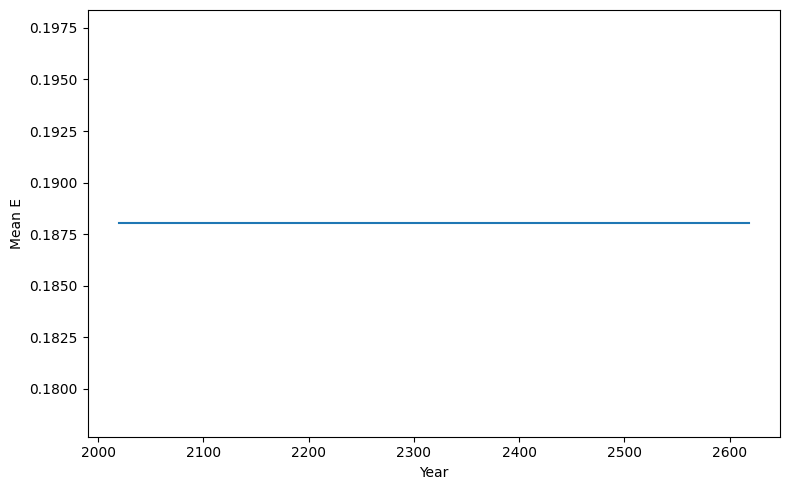

In [ ]:
# plot mean E
plt.figure(figsize=(8, 5))
plt.plot(summary_results_gs["year"], summary_results_gs["mean_E"])
plt.xlabel("Year")
plt.ylabel("Mean E")
plt.tight_layout()
plt.show()



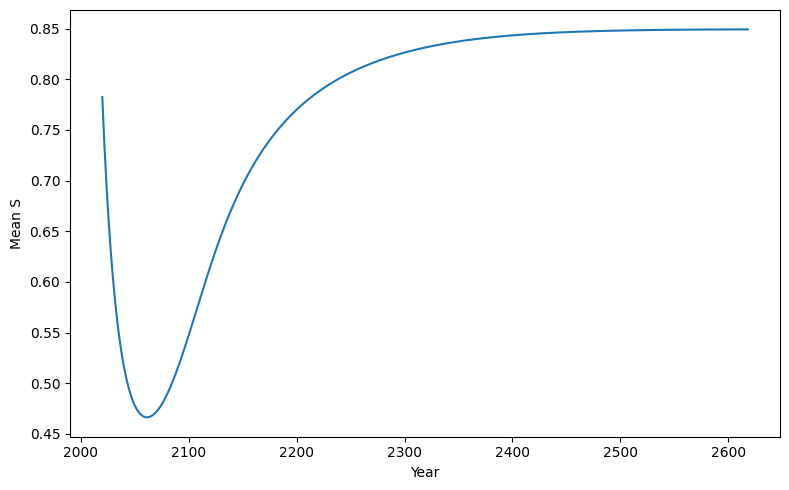

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(summary_results_gs["year"], summary_results_gs["mean_S"])
plt.xlabel("Year")
plt.ylabel("Mean S")
plt.tight_layout()
plt.show()



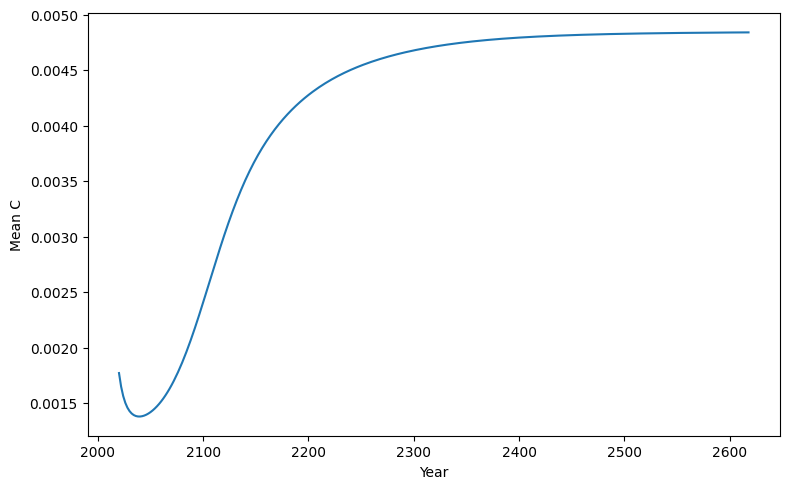

In [ ]:
# plot mean C
plt.figure(figsize=(8, 5))
plt.plot(summary_results_gs["year"], summary_results_gs["mean_C"])
plt.xlabel("Year")
plt.ylabel("Mean C")
plt.tight_layout()
plt.show()


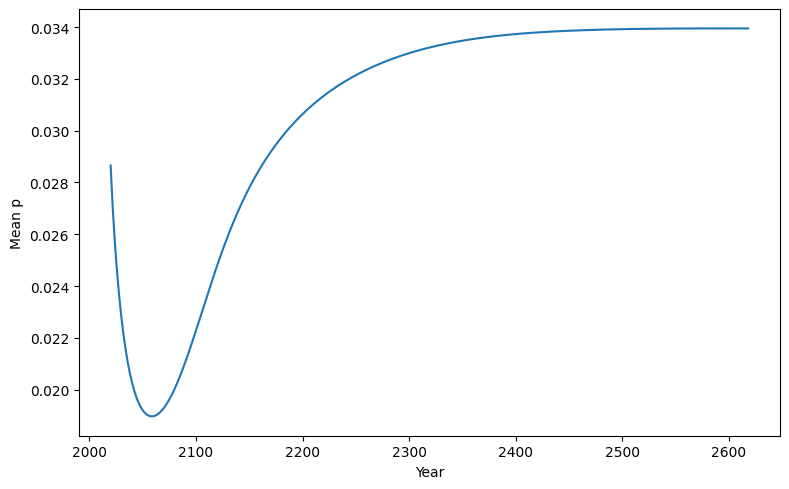

In [ ]:
# plot mean p
plt.figure(figsize=(8, 5))
plt.plot(summary_results_gs["year"], summary_results_gs["mean_p_next"])
plt.xlabel("Year")
plt.ylabel("Mean p")
plt.tight_layout()
plt.show()



---

# PSO

In [ ]:
map_steps = {
    step: 2018 + step * 2
    for step in range(1, 301, 5)
}

simulation_results_pso = run_ifm_simulation(
    **pso_params,
    n_steps=300
)

patch_results_pso = []

for step, E_i, S_i, C_i, p_next in simulation_results_pso:
    if step in map_steps:
        for i in range(len(patch_df)):
            patch_results_pso.append({
                "step": step,
                "year": map_steps[step],
                "patch_id": patch_df["patch_id"].iloc[i],
                "E_i": E_i[i],
                "S_i": S_i[i],
                "C_i": C_i[i],
                "p_next": p_next[i]
            })

patch_results_pso = pd.DataFrame(patch_results_pso)

summary_results_pso = []

for step, E_i, S_i, C_i, p_next in simulation_results_pso:
    n_pred = (p_next > 0.5).sum()

    summary_results_pso.append({
        "step": step,
        "year": 2018 + step * 2,
        "mean_E": E_i.mean(),
        "mean_S": S_i.mean(),
        "mean_C": C_i.mean(),
        "mean_p_next": p_next.mean(),
        "n_pred": n_pred
    })

summary_results_pso = pd.DataFrame(summary_results_pso)

for step, E_i, S_i, C_i, p_next in simulation_results_pso:
    n_pred = (p_next > 0.5).sum()

    print(
        step,
        n_pred,
        round(E_i.mean(), 8),
        round(S_i.mean(), 8),
        round(C_i.mean(), 8),
        round(p_next.mean(), 8)
    )

1 35 0.14729672 0.00279227 1e-07 0.03078118
2 35 0.14729672 0.0027652 1e-07 0.03045932
3 34 0.14729672 0.00274257 1e-07 0.03018586
4 34 0.14729672 0.00272329 1e-07 0.0299495
5 34 0.14729672 0.00270657 1e-07 0.0297418
6 34 0.14729672 0.0026918 1e-07 0.02955643
7 34 0.14729672 0.00267854 1e-07 0.02938862
8 34 0.14729672 0.00266645 1e-07 0.02923479
9 34 0.14729672 0.00265528 1e-07 0.02909222
10 34 0.14729672 0.00264484 1e-07 0.02895888
11 34 0.14729672 0.00263498 1e-07 0.0288332
12 33 0.14729672 0.00262561 1e-07 0.02871398
13 33 0.14729672 0.00261664 1e-07 0.0286003
14 33 0.14729672 0.00260801 1e-07 0.02849144
15 33 0.14729672 0.00259967 1e-07 0.02838685
16 33 0.14729672 0.00259159 1e-07 0.02828607
17 33 0.14729672 0.00258373 1e-07 0.02818876
18 33 0.14729672 0.00257608 9e-08 0.02809462
19 33 0.14729672 0.00256861 9e-08 0.02800342
20 33 0.14729672 0.00256132 9e-08 0.02791495
21 33 0.14729672 0.00255419 9e-08 0.02782905
22 33 0.14729672 0.00254721 9e-08 0.02774556
23 33 0.14729672 0.002540

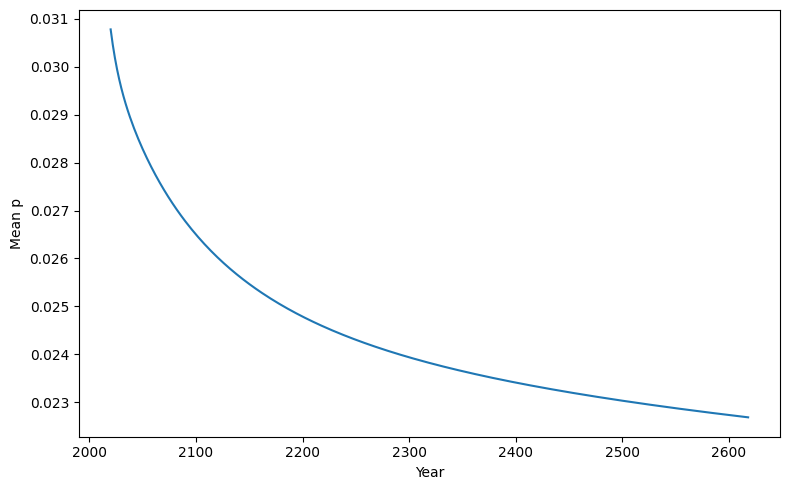

In [ ]:
# plot mean p
plt.figure(figsize=(8, 5))
plt.plot(summary_results_pso["year"], summary_results_pso["mean_p_next"])
plt.xlabel("Year")
plt.ylabel("Mean p")
plt.tight_layout()
plt.show()

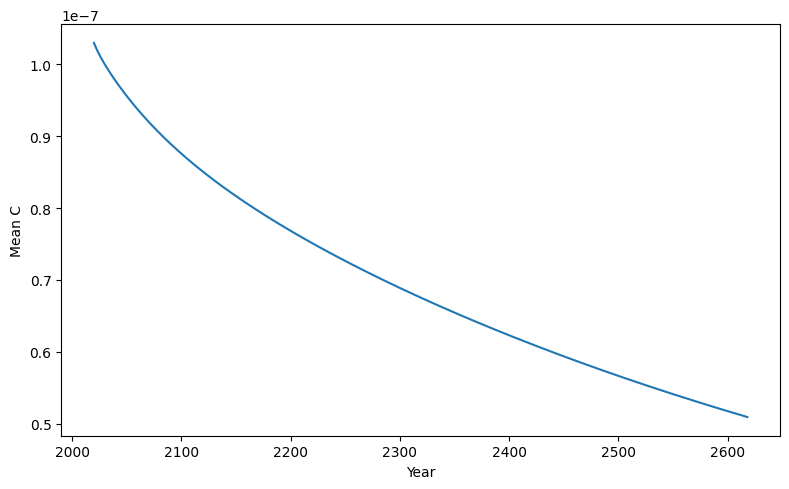

In [ ]:
# plot mean C
plt.figure(figsize=(8, 5))
plt.plot(summary_results_pso["year"], summary_results_pso["mean_C"])
plt.xlabel("Year")
plt.ylabel("Mean C")
plt.tight_layout()
plt.show()

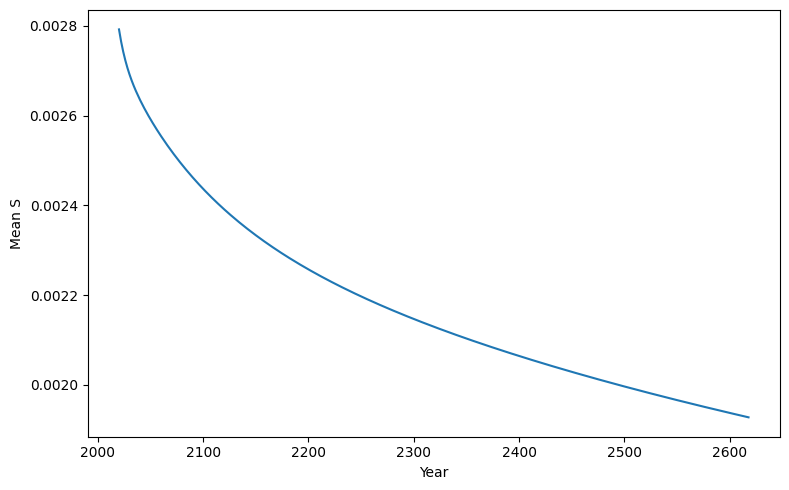

In [ ]:
# plot mean S
plt.figure(figsize=(8, 5))
plt.plot(summary_results_pso["year"], summary_results_pso["mean_S"])
plt.xlabel("Year")
plt.ylabel("Mean S")
plt.tight_layout()
plt.show()

In [ ]:
save_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"

summary_results_pso.to_csv(save_path + "kudzu_summary_results_pso.csv",
index=False)

patch_results_pso.to_csv(save_path + "kudzu_patch_results_pso.csv",
index=False)




---
# PSO-2


In [ ]:
map_steps = {
    step: 2018 + step * 2
    for step in range(1, 301, 5)
}

simulation_results_pso2nd = run_ifm_simulation(
    **pso2nd_params,
    n_steps=300
)

patch_results_pso2nd = []

for step, E_i, S_i, C_i, p_next in simulation_results_pso2nd:
    if step in map_steps:
        for i in range(len(patch_df)):
            patch_results_pso2nd.append({
                "step": step,
                "year": map_steps[step],
                "patch_id": patch_df["patch_id"].iloc[i],
                "E_i": E_i[i],
                "S_i": S_i[i],
                "C_i": C_i[i],
                "p_next": p_next[i]
            })

patch_results_pso2nd = pd.DataFrame(patch_results_pso2nd)

summary_results_pso2nd = []

for step, E_i, S_i, C_i, p_next in simulation_results_pso2nd:
    n_pred = (p_next > 0.5).sum()

    summary_results_pso2nd.append({
        "step": step,
        "year": 2018 + step * 2,
        "mean_E": E_i.mean(),
        "mean_S": S_i.mean(),
        "mean_C": C_i.mean(),
        "mean_p_next": p_next.mean(),
        "n_pred": n_pred
    })

summary_results_pso2nd = pd.DataFrame(summary_results_pso2nd)

for step, E_i, S_i, C_i, p_next in simulation_results_pso2nd:
    n_pred = (p_next > 0.5).sum()

    print(
        step,
        n_pred,
        round(E_i.mean(), 8),
        round(S_i.mean(), 8),
        round(C_i.mean(), 8),
        round(p_next.mean(), 8)
    )

1 35 0.08320055 0.00135365 1.6e-07 0.03071744
2 35 0.08320055 0.00134338 1.5e-07 0.03034697
3 34 0.08320055 0.00133432 1.5e-07 0.03003666
4 34 0.08320055 0.00132623 1.5e-07 0.02977273
5 34 0.08320055 0.00131892 1.5e-07 0.02954488
6 33 0.08320055 0.00131224 1.5e-07 0.02934532
7 33 0.08320055 0.00130609 1.5e-07 0.02916822
8 33 0.08320055 0.00130039 1.5e-07 0.02900911
9 33 0.08320055 0.00129505 1.5e-07 0.02886459
10 33 0.08320055 0.00129003 1.5e-07 0.02873206
11 33 0.08320055 0.00128529 1.5e-07 0.0286095
12 33 0.08320055 0.00128078 1.5e-07 0.02849532
13 33 0.08320055 0.00127648 1.5e-07 0.02838828
14 33 0.08320055 0.00127237 1.5e-07 0.02828739
15 33 0.08320055 0.00126843 1.5e-07 0.02819186
16 33 0.08320055 0.00126463 1.5e-07 0.02810104
17 33 0.08320055 0.00126097 1.5e-07 0.0280144
18 32 0.08320055 0.00125744 1.5e-07 0.02793152
19 32 0.08320055 0.00125401 1.5e-07 0.02785201
20 32 0.08320055 0.00125069 1.5e-07 0.02777558
21 32 0.08320055 0.00124746 1.5e-07 0.02770196
22 32 0.08320055 0.00124

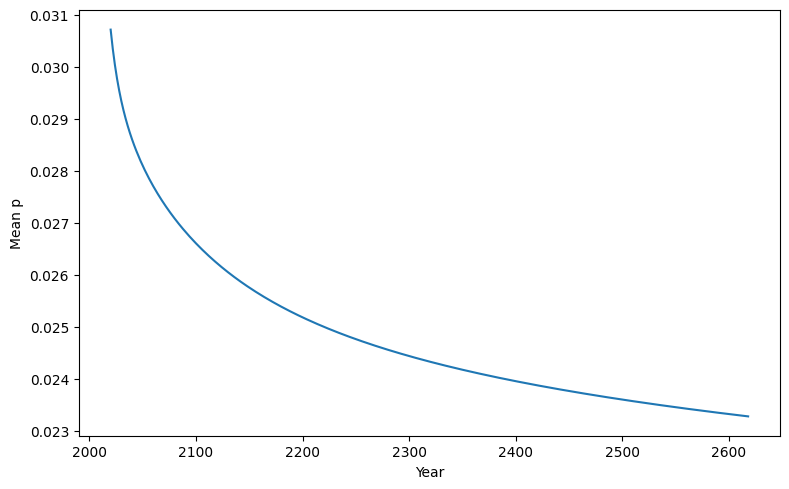

In [ ]:
# plot mean p
plt.figure(figsize=(8, 5))
plt.plot(summary_results_pso2nd["year"], summary_results_pso2nd["mean_p_next"])
plt.xlabel("Year")
plt.ylabel("Mean p")
plt.tight_layout()
plt.show()

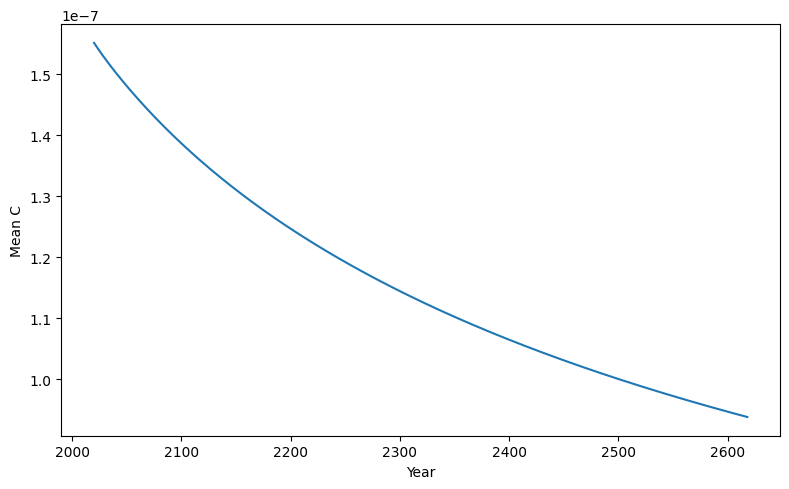

In [ ]:
# plot mean C
plt.figure(figsize=(8, 5))
plt.plot(summary_results_pso2nd["year"], summary_results_pso2nd["mean_C"])
plt.xlabel("Year")
plt.ylabel("Mean C")
plt.tight_layout()
plt.show()

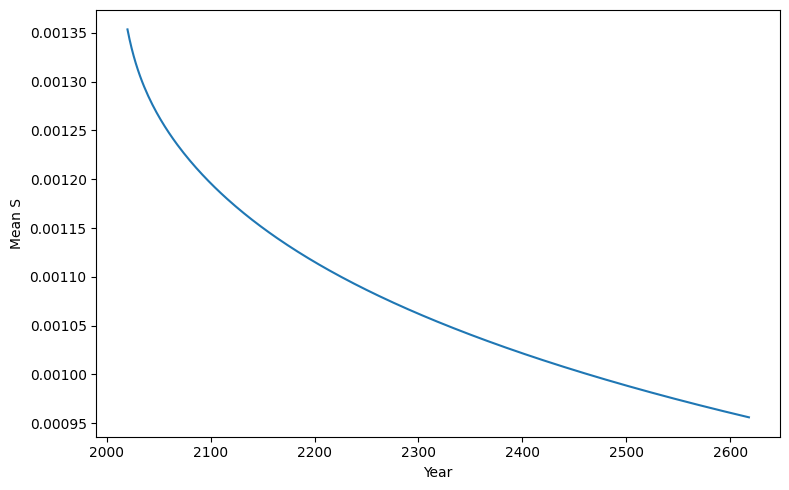

In [ ]:
# plot mean S
plt.figure(figsize=(8, 5))
plt.plot(summary_results_pso2nd["year"], summary_results_pso2nd["mean_S"])
plt.xlabel("Year")
plt.ylabel("Mean S")
plt.tight_layout()
plt.show()

In [ ]:
%whos

Variable                    Type         Data/Info
--------------------------------------------------
A_j                         ndarray      1123: 1123 elems, type `float64`, 8984 bytes
Agriculture_prop            ndarray      1123: 1123 elems, type `float64`, 8984 bytes
C_i                         ndarray      1123: 1123 elems, type `float64`, 8984 bytes
D_ij                        ndarray      1123x1123: 1261129 elems, type `float64`, 10089032 bytes (9.621650695800781 Mb)
E_i                         ndarray      1123: 1123 elems, type `float64`, 8984 bytes
Forest_prop                 ndarray      1123: 1123 elems, type `float64`, 8984 bytes
Freshwater_prop             ndarray      1123: 1123 elems, type `float64`, 8984 bytes
Marine_prop                 ndarray      1123: 1123 elems, type `float64`, 8984 bytes
O_j                         ndarray      1123: 1123 elems, type `float64`, 8984 bytes
S_i                         ndarray      1123: 1123 elems, type `float64`, 8984 bytes
Urb

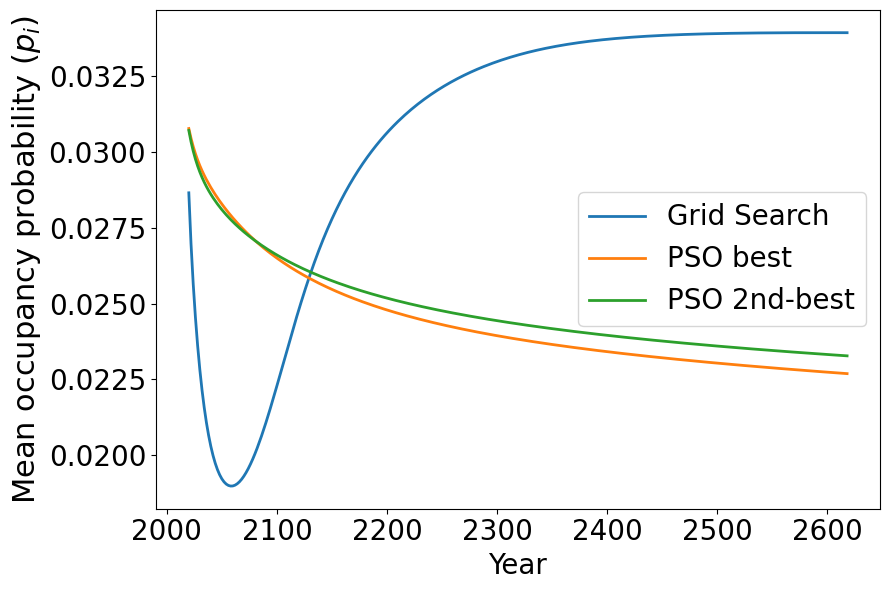

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    summary_results_gs["year"],
    summary_results_gs["mean_p_next"],
    linewidth=2,
    label="Grid Search"
)

plt.plot(
    summary_results_pso["year"],
    summary_results_pso["mean_p_next"],
    linewidth=2,
    label="PSO best"
)

plt.plot(
    summary_results_pso2nd["year"],
    summary_results_pso2nd["mean_p_next"],
    linewidth=2,
    label="PSO 2nd-best"
)

plt.xlabel("Year", fontsize=20)
plt.ylabel(r"Mean occupancy probability ($p_i$)", fontsize=22)

plt.legend(fontsize=20)
plt.tick_params(labelsize=20)

plt.tight_layout()
plt.show()

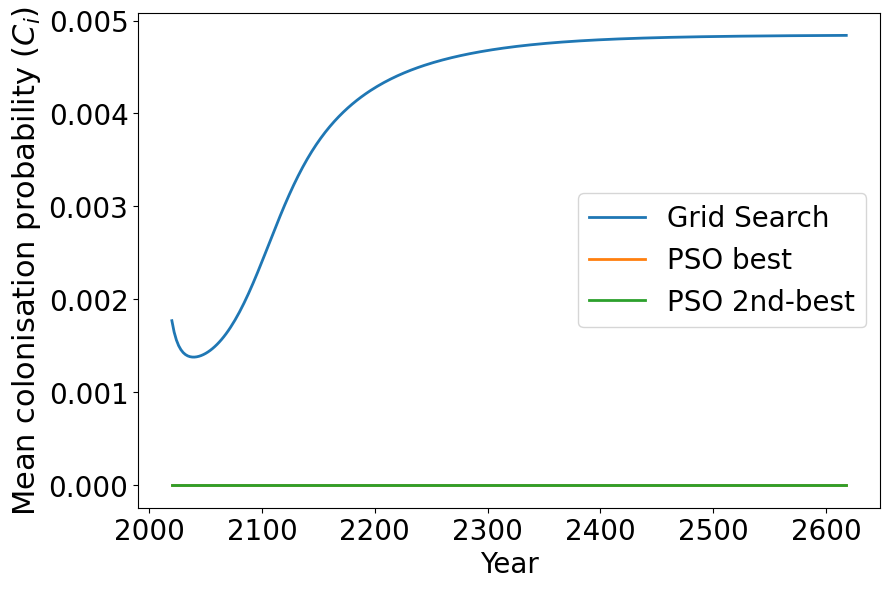

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    summary_results_gs["year"],
    summary_results_gs["mean_C"],
    linewidth=2,
    label="Grid Search"
)

plt.plot(
    summary_results_pso["year"],
    summary_results_pso["mean_C"],
    linewidth=2,
    label="PSO best"
)

plt.plot(
    summary_results_pso2nd["year"],
    summary_results_pso2nd["mean_C"],
    linewidth=2,
    label="PSO 2nd-best"
)

plt.xlabel("Year", fontsize=20)
plt.ylabel(r"Mean colonisation probability ($C_i$)", fontsize=22)

plt.legend(fontsize=20)
plt.tick_params(labelsize=20)

plt.tight_layout()
plt.show()

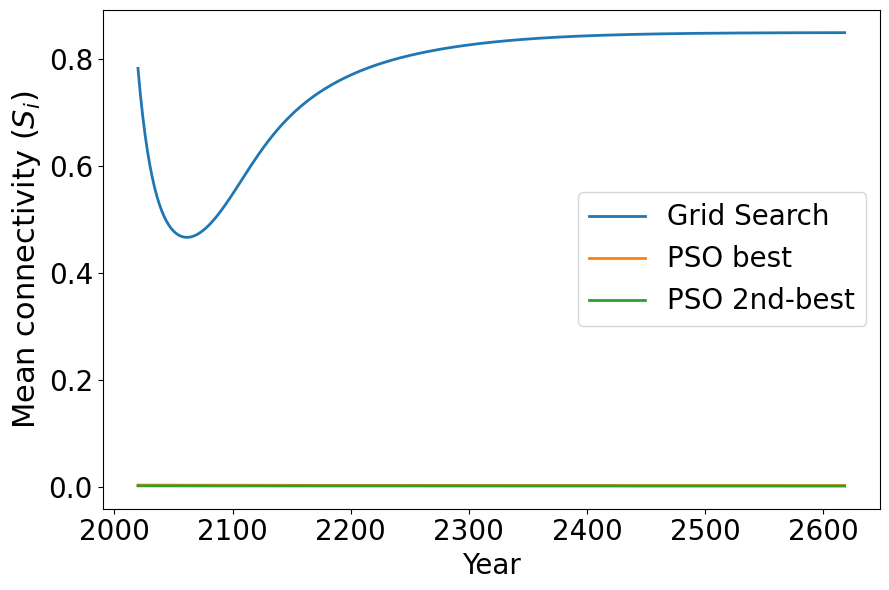

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    summary_results_gs["year"],
    summary_results_gs["mean_S"],
    linewidth=2,
    label="Grid Search"
)

plt.plot(
    summary_results_pso["year"],
    summary_results_pso["mean_S"],
    linewidth=2,
    label="PSO best"
)

plt.plot(
    summary_results_pso2nd["year"],
    summary_results_pso2nd["mean_S"],
    linewidth=2,
    label="PSO 2nd-best"
)

plt.xlabel("Year", fontsize=20)
plt.ylabel(r"Mean connectivity ($S_i$)", fontsize=22)

plt.legend(fontsize=20)
plt.tick_params(labelsize=20)

plt.tight_layout()
plt.show()